## 6. Métodos da falsa posição e do ponto fixo

### 6.1. Método da falsa posição 

Uma deficiência do método da bissecção é que, na divisão do intervalo $(a,b)$ em metades iguais, não são levados em conta os módulos de $f(a)$ e $f(b)$. Por exemplo, se $f(a)$ estiver muito mais próximo de zero do que $f(b)$, será provável que a raiz esteja mais próxima de $a$ do que de $b$. Um método alternativo que explora essa percepção gráfica é ligar $f(a)$ e $f(b)$ por uma reta. A intersecção dessa reta com o eixo $x$ representa uma estimativa melhorada da raiz. O fato de a substituição da curva por uma reta dar uma “falsa posição” da raiz é a origem do nome, método da falsa posição, ou, em latim, *regula falsi*. Ele também é chamado de método da interpolação linear ([Chapra e Canale, 2016](https://integrada.minhabiblioteca.com.br/reader/books/9788580555691/pageid/136)).
<img src="https://github.com/tiagoburiol/MatComp_I/blob/main/06_metodos_da_falsa_posicao_e_do_ponto_fixo/figuras/falsa_posicao.png?raw=true" width="500">

Figura 6.1 - Método da falsa posição

Usando triângulos semelhantes (Figura 6.1), a intersecção da reta com o eixo $x$ pode ser calculada por

$$
\frac{f\left(a\right)}{x_f-a}=\frac{f\left(b\right)}{x_f-b}
$$

que pode ser reescrita como

$$
x_f=b-\frac{f\left(b\right)\left(a-b\right)}{f\left(a\right)-f\left(b\right)}
$$

Essa é a fórmula da falsa posição. O valor de $x_p$ substitui qualquer das duas aproximações iniciais, $a$ ou $b$, que forneça um valor da função com o mesmo sinal que $f(x_f)$. Dessa forma, os valores $a$ e $b$ sempre delimitam a raiz verdadeira. O processo é repetido até que a raiz seja estimada adequadamente. O algoritmo é idêntico ao da bissecção, com a diferença de que a aproximação para a raíz é obtida pela fórmola da falsa posição.

**Exemplo 6.1:** Neste exemplo vamos usar o método da bisseção para  encontrar a raiz da equação $x^2+ln(x)-2=0$  com precisão de $\epsilon = 10^{-3}$. 

*Solução:* Reescrevendo a equação como $x^2-2=-ln(x)$ e plotando os gráficos de $f_1(x)=x^2-2$ e $f_2(x)=-ln(x)$ observamos que existe uma raiz no intervalo $[1.25,1.50]$. A raiz é a abcissa do ponto de intersecção das duas curbas.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=(4,3)

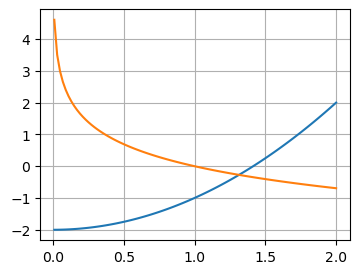

In [20]:
f1 = lambda x: x**2-2
f2 = lambda x: -np.log(x)

x = np.linspace(0.01, 2, 100)
plt.plot(x, f1(x), x, f2(x))
plt.grid()

In [21]:
a = 1.25
b = 1.50
err = 1
f = lambda x: x**2+np.log(x)-2
x_ant = a

In [22]:
while err > 10**-3:
    x = b - (f(b)*(a-b))/(f(a)-f(b))
    if f(a) * f(x) < 0:
        b = x
    else:
        a = x
    err = abs(x - x_ant) / abs(x)
    x_ant = x
    print(x, err)
print("Solução: x =", np.round(x,4) )

1.3116093171672702 0.046972308263508
1.3140003779294438 0.0018196804219655534
1.3140930666503576 7.053436569001993e-05
Solução: x = 1.3141


### 6.2. Método do ponto fixo



O método do ponto fixo (ou das aproximações sucessivas), consiste em reescrever a equação $f(x)=0 $ em uma equação equivalente $x = \phi (x)$ em que $\phi (x)$ é a de iteração. Então, a raiz $\overline{x}$ é obtida por meio de uma sequência de de soluções aproximadas, geradas pelo processo iterativo dado por

$$ x_{i+1} = \phi(x_i) , \,\,\,\,\, i = 0,1,2,...$$

Existem muitas formas diferentes de se obter a função de iteração, como é exemplificado a seguir.

**Exemplo 6.2:** Seja a equação $f(x) = x^2-5x=0$, então, algumas possíveis funções de iteração são

(a) $x_{i+1} = \phi(x_i) = \sqrt{5x_i}$

(b) $x_{i+1} = \phi(x_i) = \frac{x_i^2}{5}$

(c) $x_{i+1} = \phi(x_i) = x_i^2 - 4x_i$

**Exemplo 6.3:** Seja a equação $f(x) = x^3-x-7=0$, então, algumas possíveis funções de iteração são:

(a) $x_{i+1} = \phi(x_i) = x_{i}^3-7$

(b) $x_{i+1} = \phi(x_i) = \sqrt[3]{x_i+7}$

(c) $x_{i+1} = \phi(x_i) = \frac{7}{x_i^2-1}$

De modo geral, sempre é possível obter uma função de iteração multiplicando uma função qualquer $\theta(x)$ pela equação $f(x)=0$ e somando $x$ a ambos os lados obtendo-se 

$$x_{i+1} = \phi(x_i) = f(x)\theta(x_i)+x$$

O processo iterativo gera uma sequência de soluções aproximadas a partir de uma aproximação inicial $x_0$, como é mostrado abaixo

$$x_{1} = \phi(x_0)$$

$$x_{2} = \phi(x_1)$$

$$x_{3} = \phi(x_2)$$

$$\vdots$$

$$x_{i+1} = \phi(x_{i})\simeq \overline{x}$$

Geometricamente, interpretamos o processo iterativo como é mostrado nas figuras abaixo, para dois casos distintos. O ponto de intersecção entre o gráfico de $\phi(x)$ e a reta $y=x$ é o ponto cuja abcissa é a raiz procurada $\overline{x}$.

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_I/main/04_solucoes_equacoes_uma_variavel/figuras/convergencia_ponto-fixo.png?raw=true" width="600">
Figura 6.2 - Método do ponto fixo convergindo para a raiz


Nem sempre o método será convergente, a convergêcia dependerá da  inclinação do gráfico da função na vizinhança da raiz, como é enunciado a seguir.  

**Condição de convergência do método do ponto fixo:** Seja $\phi(x)$ uma função contínua e derivável em $I=[a,b]$ centrado em $\overline{x}$, então, se $|\phi'(x)|<1$ em $I$, a sequência ${x_k}$, $k=0,1,2,3,..$ que é dada por $x_{k+1}=\phi(x_k)$ converge para a raiz $\overline{x}$ procurada.

No caso do processo iterativo gerar sequências divergentes, uma interpretação geométrica é mostrada na figura a seguir. 

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_I/main/04_solucoes_equacoes_uma_variavel/figuras/divergencia_ponto-fixo.png?raw=true" width="600">
Figura 6.3 - Método do ponto fixo divergindo

**Observação:**
Para os exemplos computacionais a seguir precisaremos carregar as já conhecidas bibliotecas `numpy` e `matplotlib` utilizando as linhas mostradas abaixo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

**Exemplo 4.8:** Vamos usar o método do ponto fixo para encontrar uma raiz para $f(x)=x-cos(x/2)$ com $\epsilon = 10^{-3}$.

Aqui a forma mais obvia de reescrevermos a equação de modo a termos $x = \phi (x)$ é fazer $x=cos(x/2)$ o que nos fornece o processo iterativo $x_{i+1}=cos(x/2)_i$. Vamos então buscar uma boa aproximação inicial $x_0$ e avaliar a convergência. Começamos olhando os gráficos e $f_1(x)=x$ e $f_ 2(x)=cos(x/2)$.

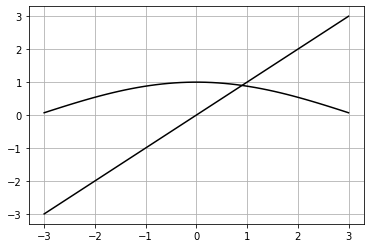

In [28]:
import numpy as np
import matplotlib.pyplot as plt
f1 = lambda x: np.cos(x/2)
f2 = lambda x: x
X = np.linspace(-3, 3)
plt.plot(X, f1(X),X, f2(X),
        color = "black") 
plt.grid()
plt.show()

Observamos que existe uma única raiz entre $0$ e $1$, tomamos então o ponto médio $x_0=0,5$ como aproximação inicial. Avaliando a função $|\phi'(x)|= |-\frac{sen(x/2)}{2}|$ em torno de $x_0=0,5$ também verificamos que $|-\frac{sen(x/2)}{2}|<1$, logo, o processo iterativo é convergente. Então, fazendo algumas iterações até que a diferença relativa $\frac{|x_i - x_{i-1}|}{|x_i|}$ atinja um valor menor que 0.001 obtemos:

$x_0=0.5$

$x_1=cos(x_0/2) = cos(0.25)= 0.968912$

$x_2=cos(x_1/2) = cos(0.968912/2)= 0.884928$

$x_3=cos(x_2/2) = cos(0.0.903699/2)= 0.0.903699$

$\vdots$


O erro após a 3ª iteração é $\frac{|x_2 - x_1|}{|x_1|} = 0.020771>10^{-3}$, então, a precisão desejada ainda não foi atingida.  Devemos prosseguir o processo iterativo. Na quinta iteração a precisão é atingida, como podemos ver ao resolver computacionalmente com o código mostrado abaixo.

In [29]:
x = 0.5
err = 1.0
x_ant = x

while err>0.001:
    x = f1(x)
    err = abs(x-x_ant)/abs(x)
    x_ant = x
    print (f' x = {x}, erro = {err}')

 x = 0.9689124217106447, erro = 0.48395748800780714
 x = 0.8849283373389375, erro = 0.09490495538232536
 x = 0.903699330715045, erro = 0.020771281706333838
 x = 0.8996410217990137, erro = 0.004511031419972279
 x = 0.9005251594201672, erro = 0.0009818022427299535


Como é possivel notar, a sequência convergiu para o ponto fixo $x \approx 0.9$.

**Exemplo 4.9:** Agora vamos calcular todas as raízes de 𝑓(𝑥)=𝑙𝑛𝑥−𝑥+2=0 pelo método ponto-fixo até que o erro relativo seja inferior a 0.0001. 

Precisamos encontrar uma função de interação $\phi (x)$ escrevendo uma equação equivalente a $f(x)=lnx−x+2=0$ na forma $x=\phi (x)$. Sabemos que existem diferentes formas de fazer isso e que as funções obtidas podem gerar sequências convergentes ou não. Se $|\phi '(x)|<1$ em torno da raiz, a sequência será convergente. Entre as equações possíveis, tem-se $\phi_1(x)=ln(x)+2$ e $\phi_2(x)=e^{x−2}$. Mas antes de fazer as iterações vamos localizar as raízes.

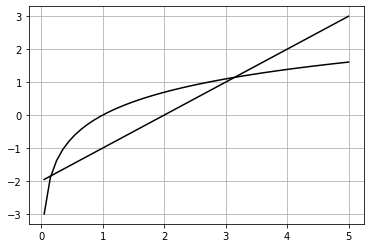

In [30]:
xi = np.linspace(0.05, 5)
plt.plot(xi, np.log(xi), xi, xi-2, color="black") 
plt.grid()
plt.show()

Fazendo os gráficos de $f_1(x)=ln(x)$ e de $f_2(x)=x-2$ vemos que há uma raiz próxima de $x=0$ e outra próximo de $x=3$. Analisando a convergência da função de iteração $\phi_1(x)=ln(x)+2$ fazendo $|\phi_1'(x)|=|1/x|$ notamos que a função converge para a raiz próxima de $x=3$ pois tem-se que $|\phi_1'(x)|=|1/x|<1$ na vizinhanca de $3$, mas o mesmo não ocorre para valores de $x$ próximos de $0$. Por outro lado, observamos que  $|\phi_2'(x)|=|e^{x−2}|<1$ na vizinhança de $x=0$ portano pode a função de iteração $\phi_2(x)$ ser usada para encontrar a menor raiz da equação.

Vamos, dessa vez, construir uma função para o método do ponto fixo

In [84]:
def pontofixo(phi,x,eps):
    err = 10.0
    x_ant = x
    
    while err>eps:
        x = phi(x)
        err = abs(x-x_ant)/abs(x)
        x_ant = x
        print ("| x=%.9f"%x, "| err=%.9f"%err)
    return (x)

A função `pontofixo` recebe a função de iteração, a aproximação iniciao e a precisão desejada e processa as iterações imprimindo os resultados até que a tolerância seja atingida. A seguir é executada para $f_1(x)=ln(x)+2$, $x_0=3$ e $\epsilon=0.0001$:

In [85]:
pontofixo(lambda x: np.log(x)+2, 3.0, 0.0001)

| x=3.098612289 | err=0.031824662
| x=3.130954362 | err=0.010329781
| x=3.141337866 | err=0.003305440
| x=3.144648781 | err=0.001052873
| x=3.145702209 | err=0.000334878
| x=3.146037143 | err=0.000106462
| x=3.146143611 | err=0.000033841


3.1461436109912895

Em 7 iterações a solução procurada foi obtida. Agora, testando para $f_2(x)=e^{x-2}$, $x_0=0.5$ e $\epsilon=0.0001$:

In [38]:
pontofixo(lambda x: np.exp(x-2), 0.5, 0.0001)

| x=0.223130160 | err=1.240844535
| x=0.169166839 | err=0.318994679
| x=0.160279973 | err=0.055445889
| x=0.158861897 | err=0.008926471
| x=0.158636778 | err=0.001419082
| x=0.158601070 | err=0.000225144
| x=0.158595407 | err=0.000035709


0.15859540701599245

Novamente foram necessárias 7 iterações.

**Exemplo 4.10:**
Vamos encontrar a menor raíz positiva de $ f(x)=2x-\tan(x)$ com $\epsilon < 0.01$.

Inicialmente precisamos localizar a menor raiz positiva da função. Sabemos que há uma raíz em $x=0$ e a outra é próxima de $\pi/2$. Para conseguir uma boa aproximação inicial, podemos calcular o valor da função para alguns valores de $x$ e fazer o gráfico:

In [46]:
for x in np.linspace(0,np.pi,10):
    print (f'f({np.round(x,3)})= {2*x-np.tan(x)}')

f(0.0)= 0.0
f(0.349)= 0.33416146653152945
f(0.698)= 0.5571637704181837
f(1.047)= 0.3623442948243185
f(1.396)= -2.8787550164267794
f(1.745)= 9.16194032360637
f(2.094)= 5.920841012355269
f(2.443)= 5.726021536761403
f(2.793)= 5.9490238406480564
f(3.142)= 6.283185307179586


Nos resultados acima, para valores da função entre 0 e $\pi$, já vemos que a menor raíz positiva está entre 1.047 e 1.396. Embora possa parecer que existe outra raiz entre 1.396 e 1.745, essa é uma conclusão errada, pois a função não é contínua em $x = \pi/2$. Fazendo o gráfico de $f_1(x)=2x$ e $f_2(x)=tan(x)$ podemos ter uma ideia melhor da localização dessa raiz e concluir que ela está próxima de $x=1.2$.

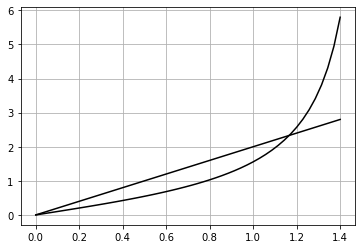

In [87]:
X = np.linspace(0,1.4,50)
plt.plot(X, np.tan(X),X, 2*X,color='k') 
plt.grid()
plt.show()


Para o método do ponto fixo, a primeira função de iteração que imaginamos é $\phi(x)=\tan(x)/2$. Mas nesse caso o método converge apenas para a raiz nula já que $|\phi'(x)|=|\tan(x)/2|$ é maior que 1 para valores próximos de $x=1.2$ como podemos ver abaixo.

In [88]:
for x in np.linspace(0.8,1.2,6):
    print ('x =',x, "phi' =",  (1/(np.cos(x))**2 ))

x = 0.8 phi' = 2.060155558164756
x = 0.88 phi' = 2.4632872860442183
x = 0.96 phi' = 3.040205121877592
x = 1.04 phi' = 3.902302747102836
x = 1.12 phi' = 5.268171142025814
x = 1.2 phi' = 7.615963967207052


Assim precisamos de uma outra função de iteração, talvez $\phi(x) = \tan^{-1}(2x)$. Podemos testar fazendo algumas iterações e verificando que está se aproximando de um valor fixo próximo de $x=1.165$.

In [53]:
pontofixo(lambda x: np.arctan(2*x), 1.2, 0.001)

| x=1.176005207 | err=0.020403645
| x=1.168783233 | err=0.006179053
| x=1.166560401 | err=0.001905459
| x=1.165871559 | err=0.000590839


1.165871558884363

Além disso, podemos verificar que a convergência é garantida para essa função de iteração já que satisfaz o critério de convergência uma vez que  $\frac{d}{dx}(tan^{-1})=\frac{1}{1+x^2}$.

#### Exercícios 
1. Calcule, se possível, as raízes das seguintes funções com pelo menos 3 casas de precisão:

a) $f(x) = \sqrt{x}-5^{-x}$  

b) $f(x) = e^{x} + x$

c) $f(x) = xln(x)-1$

d) $f(x) = sen(x)-1/2$

e) $x^3-7x^2+14x-6=0$  

f) $2x cos(2x)-(x+1)^2=0$

g) $x-2^{-x}=0$

h) $2+cos(e^x-2)-e^x=0$

i) $f(x) = –0.5x^2 + 2.5x + 4.5$

j) $f(x) = 5x^2 – 5x^2 + 6x -2$

k) $f(x) = –25 + 82x – 90x^2 + 44x^3 – 8x^4 + 0.7x^5$

l) $f(x) = – 12 – 21x + 18x^2 – 2.75x^3$